<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hackathons/dsn/000_DSN_Hackathon_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:

%matplotlib inline

In [ ]:
def get_data(filename):
    dataset_path = os.path.join(filename)
    return pd.read_csv(dataset_path)

In [ ]:
df = get_data("Housing_dataset_train.csv")

In [ ]:
df

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898
...,...,...,...,...,...,...,...
13995,6175,Edo,Bungalow,NaN,7.0,NaN,2367927.861
13996,9704,Kaduna,Apartment,NaN,7.0,5.0,2228516.471
13997,11190,Plateau,Bungalow,8.0,6.0,5.0,2406812.693
13998,9256,Delta,Flat,NaN,6.0,1.0,3348918.718


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             14000 non-null  int64  
 1   loc            12187 non-null  object 
 2   title          12278 non-null  object 
 3   bedroom        12201 non-null  float64
 4   bathroom       12195 non-null  float64
 5   parking_space  12189 non-null  float64
 6   price          14000 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 765.8+ KB


In [ ]:
df.describe()

,ID,bedroom,bathroom,parking_space,price
count,14000.000000,12201.000000,12195.000000,12189.000000,1.400000e+04
mean,4862.700357,4.308171,3.134235,3.169825,2.138082e+06
std,3818.348214,2.441165,2.035950,1.599415,1.083057e+06
min,0.000000,1.000000,1.000000,1.000000,4.319673e+05
25%,1672.750000,2.000000,1.000000,2.000000,1.393990e+06
50%,3527.000000,4.000000,2.000000,3.000000,1.895223e+06
75%,8011.250000,6.000000,5.000000,4.000000,2.586699e+06
max,12999.000000,9.000000,7.000000,6.000000,1.656849e+07


The count of ID is 14000 but it's maximum value is 12999, there seems to be some duplication in that column as it should identify one data entry and as such, its maximum value should be equal to the count.
Going by this assumption, we'll check to see if the duplication is across the columns of the entry or if it's just the ID column.

In [ ]:
df[df.duplicated(subset=['ID'],keep=False)].sort_values(by="ID").head(10)

,ID,loc,title,bedroom,bathroom,parking_space,price
12637,0,Kaduna,Townhouse,7.0,4.0,3.0,2468007.621
8591,0,Benue,Penthouse,5.0,2.0,1.0,2404653.558
8688,0,Borno,Apartment,4.0,1.0,NaN,1087381.444
9553,1,NaN,Penthouse,5.0,1.0,4.0,1634589.219
54,1,Niger,Semi-detached duplex,4.0,2.0,2.0,1476299.188
10675,1,Akwa Ibom,NaN,5.0,1.0,6.0,2772552.436
6656,2,Ebonyi,Flat,9.0,5.0,4.0,2343938.473
4118,2,Gombe,Detached duplex,5.0,2.0,1.0,1897400.277
8728,3,Imo,Semi-detached duplex,1.0,1.0,1.0,1039983.150
661,3,Jigawa,NaN,5.0,7.0,5.0,2447296.782


It seems only the ID column was duplicated as entries with the same ID hold different values. We'll remove the column.

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'bedroom'}>],
       [<Axes: title={'center': 'bathroom'}>,
        <Axes: title={'center': 'parking_space'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

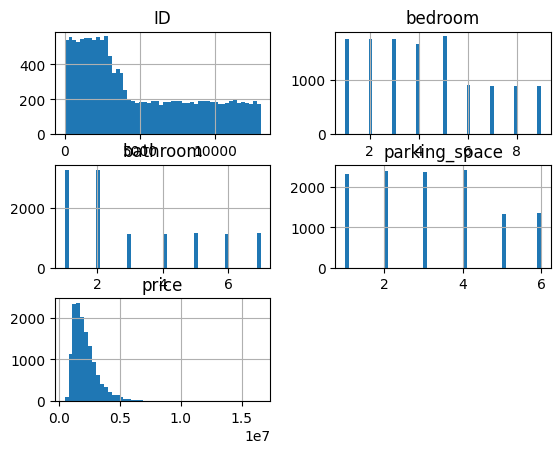

In [ ]:
df.hist(bins=50)

In [ ]:
df.corr(numeric_only=True)

,ID,bedroom,bathroom,parking_space,price
ID,1.000000,0.230474,0.345121,0.165160,0.167093
bedroom,0.230474,1.000000,0.227417,0.111095,0.529145
bathroom,0.345121,0.227417,1.000000,0.178497,0.221544
parking_space,0.165160,0.111095,0.178497,1.000000,0.109211
price,0.167093,0.529145,0.221544,0.109211,1.000000


### Get the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
seed = 99

The number of bedrooms correlates more with the price hence for our split, we'll want to make sure our test data is representative of all the various numbers of bedrooms

In [ ]:
# introduce a new column to handle bedroom na values for splitting sake
max = df["bedroom"].max() + 1
df["bedroom_cat"] = df["bedroom"].fillna(max)

In [ ]:
strat_train_val_set, strat_test_set = train_test_split(df, stratify=df["bedroom_cat"], test_size=0.15, random_state=99)
strat_train_set, strat_val_set = train_test_split(strat_train_val_set, stratify=strat_train_val_set["bedroom_cat"], test_size=0.2, random_state=99)

In [ ]:
# dropping the bedroom cat attribute since it was only useful for splitting
for set_ in (strat_test_set, strat_train_set, strat_val_set):
    set_.drop(columns=["bedroom_cat"], inplace=True)

In [ ]:
# def remove_irrelevant_columns(df):
#     return df.drop(columns=["ID"])

def get_Xy_data(df):
#     df = remove_irrelevant_columns(df)
    x_cols = ["loc", "title", "bedroom", "bathroom", "parking_space"]
    y_col = "price"
    X_train = df[x_cols]
    y_train = df[y_col]
    return X_train, y_train

### Explore the Data

In [ ]:
from pandas.plotting import scatter_matrix

In [ ]:
colscols = ["bedroom", "bathroom", "parking_space", "price"]
scatter_matrix(strat_train_set[cols])

KeyError: ignored

In [ ]:
new_df = strat_train_set.copy()

In [ ]:
new_df["bathroom_per_room"] = new_df["bathroom"] / new_df["bedroom"]
new_df["park_space_per_room"] = new_df["parking_space"] / new_df["bedroom"]
new_df["bath_park_space"] = new_df["bathroom_per_room"] + new_df["park_space_per_room"]

In [ ]:
new_df

,ID,loc,title,bedroom,bathroom,parking_space,price
3729,9707,Niger,Terrace duplex,6.0,2.0,2.0,1986186.185
3455,7443,Jigawa,Penthouse,1.0,4.0,5.0,1432662.471
9293,11757,Niger,Detached duplex,3.0,6.0,NaN,1810018.933
5901,828,Anambra,NaN,4.0,1.0,1.0,1580751.452
5093,12046,Anambra,Bungalow,1.0,1.0,5.0,1150434.651
...,...,...,...,...,...,...,...
294,1280,Kwara,Mansion,2.0,2.0,NaN,1447774.134
8543,2663,Kebbi,NaN,3.0,6.0,4.0,1535730.145
11954,11501,Taraba,Townhouse,6.0,NaN,6.0,2367693.054
2027,10223,NaN,Flat,5.0,1.0,6.0,1530309.163


In [ ]:
new_df["bedroom"].mode()

0    5.0
Name: bedroom, dtype: float64

In [ ]:
new_df[new_df["title"] == "NaN"]

,ID,loc,title,bedroom,bathroom,parking_space,price


In [ ]:
cols = ["bedroom", "bathroom", "parking_space", "price", "bathroom_per_room", "park_space_per_room"]
new_df[cols].corr()["price"]

bedroom                0.532544
bathroom               0.218791
parking_space          0.100554
price                  1.000000
bathroom_per_room     -0.197742
park_space_per_room   -0.296024
Name: price, dtype: float64

### Prepare the Data

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
new_df = strat_train_set.copy()

In [ ]:
num_cols = ["bedroom", "bathroom", "parking_space"]
cat_cols = ["loc", "title"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# There may be no need for scaling as the attributes have similar scales

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
class CustomAttribsAdder(BaseEstimator, TransformerMixin):
    def __init__(self, merge_loc_title=False):
        self.merge_loc_title = merge_loc_title
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if self.merge_loc_title:
            loc_title = X[:, loc_ix] + X[:, title_ix]
            return np.c_[X, loc_title]
        else:
            park_space_per_room = X[:, parking_space_ix] / X[:, bedrooms_ix]
            bathroom_per_room = X[:, bathrooms_ix] / X[:, bedrooms_ix]
            park_space_per_bath = X[:, parking_space_ix] / X[:, bathrooms_ix]
            return np.c_[X, bathroom_per_room, park_space_per_room]

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        print(X, "ft")
        sample_weight = y.copy()
        y = None
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!
    def transform(self, X):
        print(X, "tm")
        c =rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
        return np.c_[X, c]
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
bedrooms_ix, bathrooms_ix, parking_space_ix = 0, 1, 2
loc_ix, title_ix = 0, 1

In [ ]:
cluster_simil?

In [ ]:
cluster_simil = ClusterSimilarity(n_clusters=5, gamma=1., random_state=42)

similarities = cluster_simil.fit_transform(X,
                                           sample_weight=y_train)

      bedroom  bathroom  parking_space
0         6.0  2.000000       2.000000
1         1.0  4.000000       5.000000
2         3.0  6.000000       3.156344
3         4.0  1.000000       1.000000
4         1.0  1.000000       5.000000
...       ...       ...            ...
9515      2.0  2.000000       3.156344
9516      3.0  6.000000       4.000000
9517      6.0  3.128282       6.000000
9518      5.0  1.000000       6.000000
9519      2.0  1.000000       3.000000

[9520 rows x 3 columns] ft


AttributeError: ignored

In [ ]:
cat_pipeline = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="constant")),
    ("cat_custom_attribs", CustomAttribsAdder(merge_loc_title=True)),
    ("cat_encoder", OneHotEncoder()),
])
num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer()),
    ("cluster", ClusterSimilarity(n_clusters=50, gamma=1., random_state=42)),
    ("num_custom_attribs", CustomAttribsAdder()),
    ("std_scaler", StandardScaler())

])

In [ ]:
full_pipeline = ColumnTransformer([
    ("num_pipeline", num_pipeline, num_cols),
    ("cat_pipeline", cat_pipeline, cat_cols),
])

In [ ]:
[[1.82005102e-10, 7.51389465e-02, 8.10360317e-08, 6.71149920e-10,
        1.64570917e-03]

In [ ]:
X = full_pipeline.fit_transform(new_df, y=y_train)

[[6.         2.         2.        ]
 [1.         4.         5.        ]
 [3.         6.         3.15634432]
 ...
 [6.         3.12828234 6.        ]
 [5.         1.         6.        ]
 [2.         1.         3.        ]] ft


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


[[6.         2.         2.        ]
 [1.         4.         5.        ]
 [3.         6.         3.15634432]
 ...
 [6.         3.12828234 6.        ]
 [5.         1.         6.        ]
 [2.         1.         3.        ]] tm


In [ ]:
X[0].toarray()

array([[ 0.74340194, -0.59378984, -0.77403482, -0.63633036, -0.71969597,
        -0.13549531, -0.36387486, -0.14613015, -0.17993268, -0.14858393,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [ ]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(new_df[["price"]])

### ShortList Promising Models

In [ ]:
def display_scores(scores):
    print(f"Mean Score: {scores.mean()}\n Std Deviation: {scores.std()}")

In [ ]:
def shortListModels(models, X_train, y_train):
    for model in models:
        print(f"Running {model}")
        # single short train
#         model = model_class()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        mse = mean_squared_error(y_train, y_pred)
        rmse = np.sqrt(mse) # single shot rmse

        print("single shot scores")
        display_scores(rmse)

#         model = model_class()
        # cross validate
        scores = cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=5)
        cv_rmse = np.sqrt(-scores) # cross validate rmse
        print("cross val scores")
        display_scores(cv_rmse)
        print("\n")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
### Random Forest

In [ ]:
forest_reg = RandomForestRegressor(n_estimators=94, max_features=28,
                    max_depth=30, min_samples_split=20, min_samples_leaf=1, random_state=seed)
linear_reg = LinearRegression()
knn_reg = KNeighborsRegressor()

In [ ]:
new_df = strat_train_set.copy()
#.drop(columns=["ID"]).drop_duplicates()
y_train = new_df["price"].to_numpy()
X_train_prepared = full_pipeline.fit_transform(new_df, y_train)
y_val = strat_val_set["price"].to_numpy()
X_val_prepared = full_pipeline.transform(strat_val_set)
# X_test = full_pipeline.transform(df)
# new_df.iloc[outlier_pred == 1]

[[6.         2.         2.        ]
 [1.         4.         5.        ]
 [3.         6.         3.15634432]
 ...
 [6.         3.12828234 6.        ]
 [5.         1.         6.        ]
 [2.         1.         3.        ]] ft


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


[[6.         2.         2.        ]
 [1.         4.         5.        ]
 [3.         6.         3.15634432]
 ...
 [6.         3.12828234 6.        ]
 [5.         1.         6.        ]
 [2.         1.         3.        ]] tm
[[4.         3.12828234 3.        ]
 [2.         7.         2.        ]
 [2.         1.         4.        ]
 ...
 [4.         7.         3.        ]
 [4.         1.         1.        ]
 [4.         1.         4.        ]] tm


In [ ]:
new_df

,loc,title,bedroom,bathroom,parking_space,price
3729,Niger,Terrace duplex,6.0,2.0,2.0,1986186.185
3455,Jigawa,Penthouse,1.0,4.0,5.0,1432662.471
9293,Niger,Detached duplex,3.0,6.0,NaN,1810018.933
5901,Anambra,NaN,4.0,1.0,1.0,1580751.452
5093,Anambra,Bungalow,1.0,1.0,5.0,1150434.651
...,...,...,...,...,...,...
294,Kwara,Mansion,2.0,2.0,NaN,1447774.134
8543,Kebbi,NaN,3.0,6.0,4.0,1535730.145
11954,Taraba,Townhouse,6.0,NaN,6.0,2367693.054
2027,NaN,Flat,5.0,1.0,6.0,1530309.163


In [ ]:
models = [linear_reg, voting_reg ]
shortListModels(models, X_train_prepared, y_train)

Running LinearRegression()
single shot scores
Mean Score: 507239.89756886737
 Std Deviation: 0.0
cross val scores
Mean Score: 530204.2722749251
 Std Deviation: 58224.66189871485


Running RandomForestRegressor(max_depth=30, max_features=28, min_samples_split=20,
                      n_estimators=94, random_state=99)
single shot scores
Mean Score: 506834.61569005257
 Std Deviation: 0.0
cross val scores
Mean Score: 652633.1730265717
 Std Deviation: 67997.18759364498




In [ ]:
Running LinearRegression()
single shot scores
Mean Score: 515649.03361599357
 Std Deviation: 0.0
cross val scores
Mean Score: 531959.3896440798
 Std Deviation: 55405.00579555264


Running RandomForestRegressor(max_depth=30, max_features=28, min_samples_split=20,
                      n_estimators=94, random_state=99)
single shot scores
Mean Score: 487445.8862903521
 Std Deviation: 0.0
cross val scores
Mean Score: 567830.7419293912
 Std Deviation: 55793.870398881634

SyntaxError: ignored

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
voting_reg = VotingRegressor(
    estimators=[
        ("lin_reg", LinearRegression()),
        ("forest_reg", RandomForestRegressor(n_estimators=94, max_features=28,
                    max_depth=30, min_samples_split=20, min_samples_leaf=1, random_state=seed))
    ]
)

In [ ]:
voting_reg.fit(X_train_prepared, y_train)

VotingRegressor(estimators=[('lin_reg', LinearRegression()),
                            ('forest_reg',
                             RandomForestRegressor(max_depth=30,
                                                   max_features=28,
                                                   min_samples_split=20,
                                                   n_estimators=94,
                                                   random_state=99))])

In [ ]:
y_pred = voting_reg.predict(X_val_prepared)

In [ ]:
np.sqrt(mean_squared_error(y_val, y_pred))

601808.0025916478

In [ ]:
y_pred_lin = linear_reg.predict(X_val_prepared)
np.sqrt(mean_squared_error(y_val, y_pred_lin))

601959.7485759165

In [ ]:
600875.9486856251 == best score on validation

In [ ]:
from itertools import product

In [ ]:
states = ['Abia', 'Adamawa', 'Akwa Ibom', 'Anambra', 'Bauchi', 'Bayelsa', 'Benue', 'Borno', 'Cross River', 'Delta', 'Ebonyi', 'Edo', 'Ekiti', 'Enugu', 'Gombe', 'Imo', 'Jigawa', 'Kaduna', 'Kano', 'Katsina', 'Kebbi', 'Kogi', 'Kwara', 'Lagos', 'Nasarawa', 'Niger', 'Ogun', 'Ondo', 'Osun', 'Oyo', 'Plateau', 'Rivers', 'Sokoto', 'Taraba', 'Yobe', 'Zamfara']
loc = ['Apartment', 'Bungalow', 'Cottage','Detached duplex','Flat','Mansion','Penthouse','Semi-detached duplex','Terrace duplex',
 'Townhouse',]

In [ ]:
mansion cottage. adamawa , terrace duplex

In [ ]:
for loc, title in product(states, loc):
    search_space = new_df[(new_df["title"] == title) & (new_df["loc"] == loc)]
    X_ss_prepared = full_pipeline.transform(search_space)
    y_ss = search_space["price"]
    y_pred_ss = linear_reg.predict(X_ss_prepared)
    mse = mean_squared_error(y_ss, y_pred_ss)
    rmse = np.sqrt(mse)
    if rmse > 350_000 and title != "Mansion":
        print(f"Loc: {loc}. Title: {title}. Score: {rmse}")

Loc: Bayelsa. Title: Detached duplex. Score: 447402.2591716435
Loc: Bayelsa. Title: Semi-detached duplex. Score: 376206.2008285224
Loc: Bayelsa. Title: Terrace duplex. Score: 371556.6225147476
Loc: Delta. Title: Cottage. Score: 379185.10741377255
Loc: Delta. Title: Penthouse. Score: 450716.2802414965
Loc: Edo. Title: Penthouse. Score: 375462.1616647847
Loc: Gombe. Title: Cottage. Score: 370833.6344990649
Loc: Kebbi. Title: Townhouse. Score: 384168.9348562466
Loc: Lagos. Title: Apartment. Score: 742353.3961055431
Loc: Lagos. Title: Bungalow. Score: 674962.7422162255
Loc: Lagos. Title: Cottage. Score: 1150036.0001830626
Loc: Lagos. Title: Detached duplex. Score: 918956.3339589675
Loc: Lagos. Title: Flat. Score: 783958.2856246149
Loc: Lagos. Title: Penthouse. Score: 1475427.0835633765
Loc: Lagos. Title: Semi-detached duplex. Score: 614645.8020280559
Loc: Lagos. Title: Terrace duplex. Score: 834504.9783859272
Loc: Lagos. Title: Townhouse. Score: 1018336.8281306832
Loc: Ogun. Title: Semi-de

In [ ]:
new_df

,ID,loc,title,bedroom,bathroom,parking_space,price
3729,9707,Niger,Terrace duplex,6.0,2.0,2.0,1986186.185
3455,7443,Jigawa,Penthouse,1.0,4.0,5.0,1432662.471
9293,11757,Niger,Detached duplex,3.0,6.0,NaN,1810018.933
5901,828,Anambra,NaN,4.0,1.0,1.0,1580751.452
5093,12046,Anambra,Bungalow,1.0,1.0,5.0,1150434.651
...,...,...,...,...,...,...,...
294,1280,Kwara,Mansion,2.0,2.0,NaN,1447774.134
8543,2663,Kebbi,NaN,3.0,6.0,4.0,1535730.145
11954,11501,Taraba,Townhouse,6.0,NaN,6.0,2367693.054
2027,10223,NaN,Flat,5.0,1.0,6.0,1530309.163


In [ ]:
title = "Mansion"
loc = "Lagos"
search_space = new_df[(new_df["title"] == title) & (new_df["loc"] == loc)]
X_ss_prepared = full_pipeline.transform(search_space)
y_ss = search_space["price"]
y_pred_ss = linear_reg.predict(X_ss_prepared)
mse = mean_squared_error(y_ss, y_pred_ss)
rmse = np.sqrt(mse)
print(rmse)

3243345.7082103724


In [ ]:
search_space["y_pred"] = y_pred_ss
search_space["bath_space"] = search_space["bathroom"] / search_space["bedroom"]
search_space["park_space"] = search_space["parking_space"] / search_space["bedroom"]
search_space["bath_park"] = search_space["bathroom"] / search_space["parking_space"]
search_space["importance_factor"] = (0.45 * search_space["bedroom"]) + (0.45 * search_space["bathroom"]) + (0.1 * search_space["parking_space"])
cd = search_space[["bedroom", "bathroom", "parking_space", "importance_factor", "bath_space", "park_space", "bath_park", "price", "y_pred"]]

<ipython-input-323-fe0d0f9cfc4b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  search_space["y_pred"] = y_pred_ss
<ipython-input-323-fe0d0f9cfc4b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  search_space["bath_space"] = search_space["bathroom"] / search_space["bedroom"]
<ipython-input-323-fe0d0f9cfc4b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

array([[<Axes: xlabel='bedroom', ylabel='bedroom'>,
        <Axes: xlabel='bathroom', ylabel='bedroom'>,
        <Axes: xlabel='price', ylabel='bedroom'>],
       [<Axes: xlabel='bedroom', ylabel='bathroom'>,
        <Axes: xlabel='bathroom', ylabel='bathroom'>,
        <Axes: xlabel='price', ylabel='bathroom'>],
       [<Axes: xlabel='bedroom', ylabel='price'>,
        <Axes: xlabel='bathroom', ylabel='price'>,
        <Axes: xlabel='price', ylabel='price'>]], dtype=object)

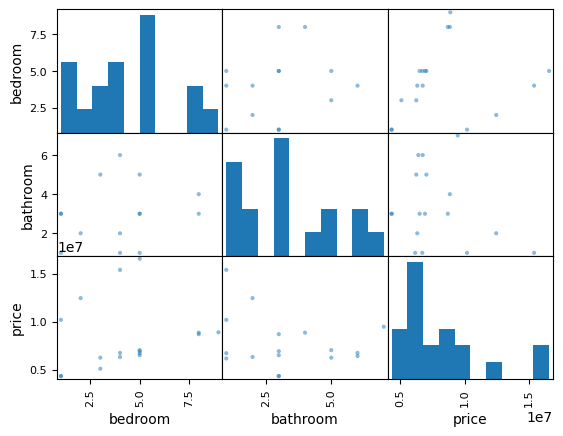

In [ ]:
scatter_matrix(cd[["bedroom", "bathroom", "price"]])

In [ ]:
search_space[["bedroom", "bathroom", "parking_space", "bath_space", "park_space", "bath_park", "price", "y_pred"]].corr()

,bedroom,bathroom,parking_space,bath_space,park_space,bath_park,price,y_pred
bedroom,1.000000,-0.322482,0.278252,-0.626457,-0.493500,-0.438602,0.650209,0.957558
bathroom,-0.322482,1.000000,0.180129,0.747401,-0.037447,0.634722,0.036541,-0.017993
parking_space,0.278252,0.180129,1.000000,-0.359720,0.670962,-0.480723,0.190209,0.338623
bath_space,-0.626457,0.747401,-0.359720,1.000000,0.070959,0.919492,-0.293288,-0.467316
park_space,-0.493500,-0.037447,0.670962,0.070959,1.000000,-0.251677,-0.134988,-0.404087
bath_park,-0.438602,0.634722,-0.480723,0.919492,-0.251677,1.000000,-0.100460,-0.336154
price,0.650209,0.036541,0.190209,-0.293288,-0.134988,-0.100460,1.000000,0.625163
y_pred,0.957558,-0.017993,0.338623,-0.467316,-0.404087,-0.336154,0.625163,1.000000


<Axes: xlabel='bedroom', ylabel='bathroom'>

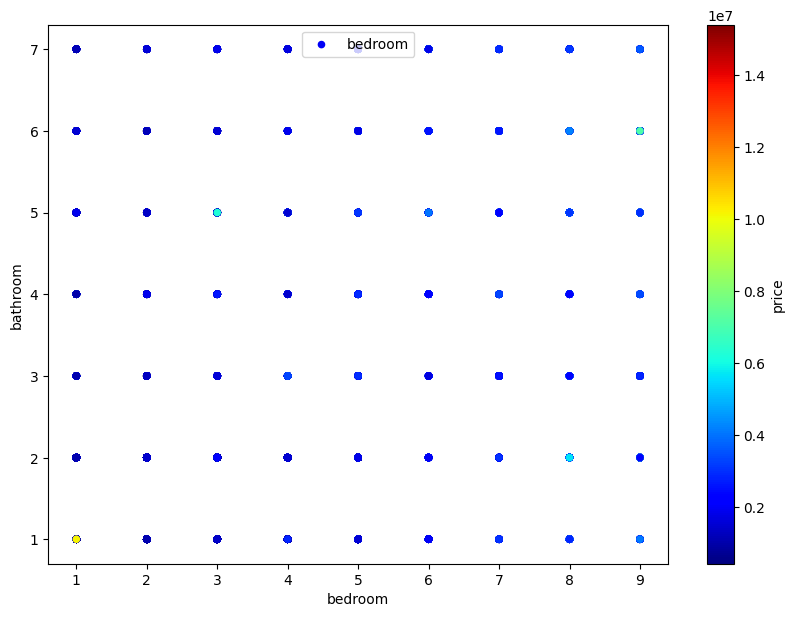

In [ ]:
new_df.plot(kind="scatter", x="bedroom", y="bathroom", label="bedroom", figsize=(10,7),
 c="price", cmap=plt.get_cmap("jet"), colorbar=True,
)
# plt.legend()


<Axes: xlabel='bedroom', ylabel='parking_space'>

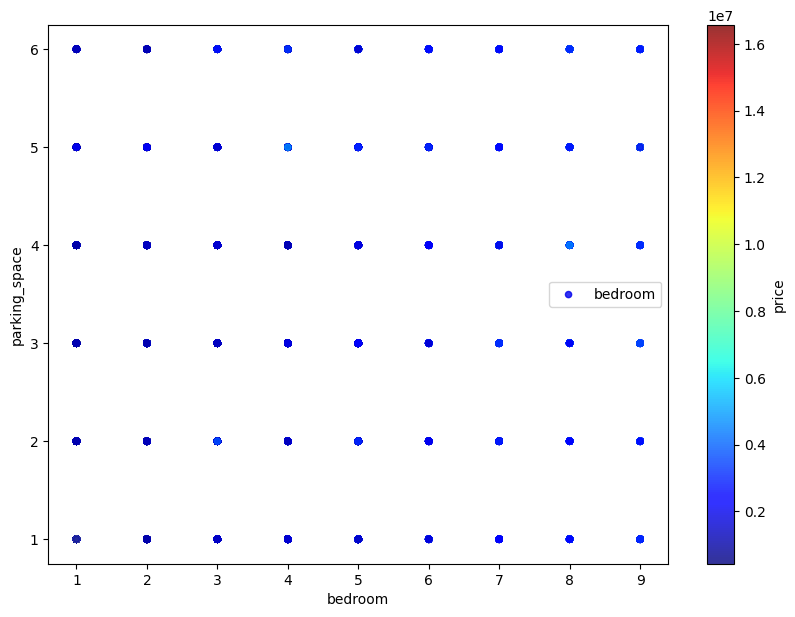

In [ ]:
new_df.plot(kind="scatter", x="bedroom", y="parking_space", label="bedroom", figsize=(10,7),
 c="price", cmap=plt.get_cmap("jet"), colorbar=True, alpha=0.8
)

In [ ]:
search_space.index = range(len(search_space))

In [ ]:
search_space

,loc,title,bedroom,bathroom,parking_space,price,y_pred,bath_space,park_space,bath_park,importance_factor
0,Lagos,Mansion,5.0,5.0,3.0,7.029926e+06,8.581886e+06,1.000000,0.600000,1.666667,4.80
1,Lagos,Mansion,2.0,2.0,1.0,1.245958e+07,7.669254e+06,1.000000,0.500000,2.000000,1.90
2,Lagos,Mansion,4.0,2.0,NaN,6.320365e+06,8.181364e+06,0.500000,NaN,NaN,NaN
3,Lagos,Mansion,9.0,NaN,1.0,8.890611e+06,9.326160e+06,NaN,0.111111,NaN,NaN
4,Lagos,Mansion,5.0,3.0,5.0,6.923899e+06,8.513173e+06,0.600000,1.000000,0.600000,4.10
5,Lagos,Mansion,NaN,6.0,6.0,6.405944e+06,8.564075e+06,NaN,NaN,1.000000,NaN
6,Lagos,Mansion,5.0,3.0,1.0,6.503583e+06,8.410344e+06,0.600000,0.200000,3.000000,3.70
7,Lagos,Mansion,3.0,NaN,1.0,5.090086e+06,7.962031e+06,NaN,0.333333,NaN,NaN
8,Lagos,Mansion,8.0,4.0,6.0,8.855421e+06,9.272321e+06,0.500000,0.750000,0.666667,6.00
9,Lagos,Mansion,8.0,3.0,6.0,8.697328e+06,9.211235e+06,0.375000,0.750000,0.500000,5.55


<Axes: >

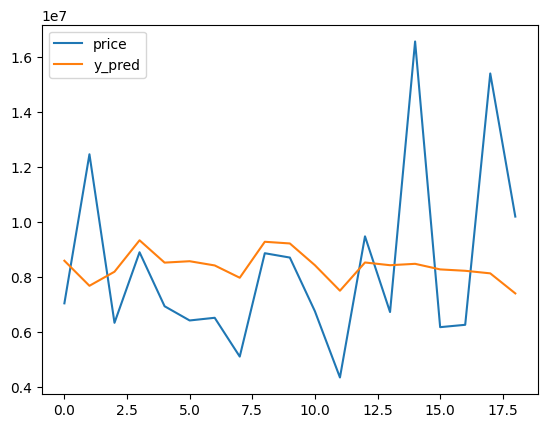

In [ ]:
search_space[["price", "y_pred"]].plot()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        print(sample_weight)
        print(X, "ft")
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!
    def transform(self, X):

        print(X, "tm")
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
imputer = SimpleImputer()
x = imputer.fit_transform(new_df[["bedroom", "bathroom", "parking_space"]])

In [ ]:
X = pd.DataFrame(x, columns=["bedroom", "bathroom", "parking_space"])
#X

In [ ]:
cluster_simil = ClusterSimilarity(n_clusters=5, gamma=1., random_state=42)

In [ ]:
similarities = cluster_simil.fit_transform(X,
                                           sample_weight=y_train)

[1986186.185 1432662.471 1810018.933 ... 2367693.054 1530309.163
 1028599.794]
      bedroom  bathroom  parking_space
0         6.0  2.000000       2.000000
1         1.0  4.000000       5.000000
2         3.0  6.000000       3.156344
3         4.0  1.000000       1.000000
4         1.0  1.000000       5.000000
...       ...       ...            ...
9515      2.0  2.000000       3.156344
9516      3.0  6.000000       4.000000
9517      6.0  3.128282       6.000000
9518      5.0  1.000000       6.000000
9519      2.0  1.000000       3.000000

[9520 rows x 3 columns] ft


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


      bedroom  bathroom  parking_space
0         6.0  2.000000       2.000000
1         1.0  4.000000       5.000000
2         3.0  6.000000       3.156344
3         4.0  1.000000       1.000000
4         1.0  1.000000       5.000000
...       ...       ...            ...
9515      2.0  2.000000       3.156344
9516      3.0  6.000000       4.000000
9517      6.0  3.128282       6.000000
9518      5.0  1.000000       6.000000
9519      2.0  1.000000       3.000000

[9520 rows x 3 columns] tm


In [ ]:
X[0].toarray()

array([[ 0.74340194, -0.59378984, -0.77403482, -0.63633036, -0.71969597,
        -0.13549531, -0.36387486, -0.14613015, -0.17993268, -0.14858393,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [ ]:
similarities[:3]

array([[1.82005102e-10, 7.51389465e-02, 8.10360317e-08, 6.71149920e-10,
        1.64570917e-03],
       [1.08333567e-05, 3.61489611e-10, 8.80472684e-05, 1.09232161e-22,
        2.18457873e-22],
       [5.07040141e-01, 8.38333079e-09, 7.21724954e-08, 3.75358027e-10,
        1.64807117e-15]])

In [ ]:
similarities[:3]

array([[2.11940778e-03, 4.34983527e-08, 9.87601360e-10, 6.78062709e-11,
        7.02207279e-02],
       [5.08940032e-22, 9.24371861e-05, 3.59678320e-22, 3.34004482e-05,
        3.41027380e-10],
       [2.50564833e-15, 4.05203021e-08, 7.90077559e-10, 5.42223738e-01,
        5.99702741e-09]])

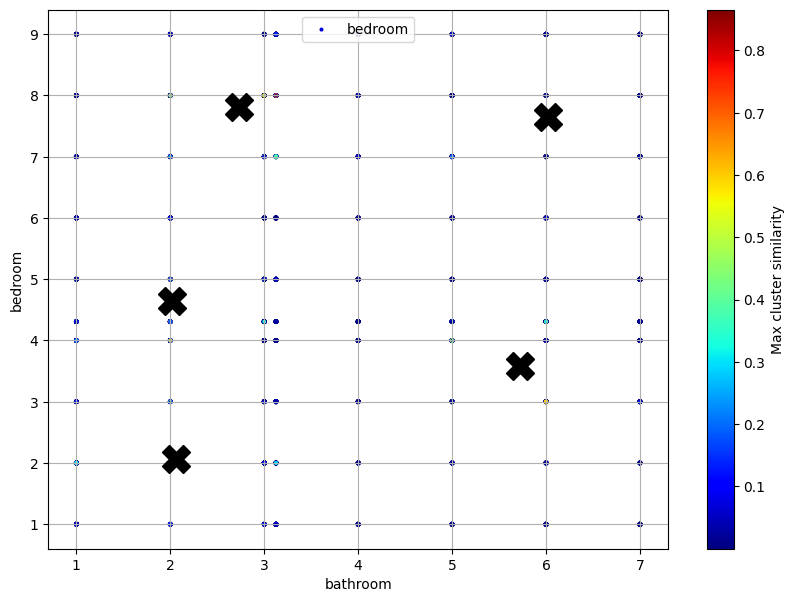

In [ ]:
# extra code – this cell generates Figure 2–19

housing_renamed = X
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="bathroom", y="bedroom", grid=True,
                     s=housing_renamed["parking_space"] , label="bedroom",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
# plt.legend(loc="upper right")
# save_fig("district_cluster_plot")
# plt.show()

In [ ]:
new_df

,ID,loc,title,bedroom,bathroom,parking_space,price
3729,9707,Niger,Terrace duplex,6.0,2.0,2.0,1986186.185
3455,7443,Jigawa,Penthouse,1.0,4.0,5.0,1432662.471
9293,11757,Niger,Detached duplex,3.0,6.0,NaN,1810018.933
5901,828,Anambra,NaN,4.0,1.0,1.0,1580751.452
5093,12046,Anambra,Bungalow,1.0,1.0,5.0,1150434.651
...,...,...,...,...,...,...,...
294,1280,Kwara,Mansion,2.0,2.0,NaN,1447774.134
8543,2663,Kebbi,NaN,3.0,6.0,4.0,1535730.145
11954,11501,Taraba,Townhouse,6.0,NaN,6.0,2367693.054
2027,10223,NaN,Flat,5.0,1.0,6.0,1530309.163


In [ ]:
df["price"] = y_pred_lin

In [ ]:
df.to_csv?

In [ ]:
df[["ID", "price"]].to_csv("my_first_submission.csv", index=False)

In [ ]:
y_pred_fr = forest_reg.predict(X_val_prepared)
np.sqrt(mean_squared_error(y_val, y_pred_fr))

557949.6721836908

In [ ]:
shortListModels([voting_reg], X_train_prepared, y_train)

Running VotingRegressor(estimators=[('lin_reg', LinearRegression()),
                            ('forest_reg',
                             RandomForestRegressor(max_features=28,
                                                   n_estimators=94))])


KeyboardInterrupt: 

The linearRegression model seems to be underfitting the model, as it is not regularized, this means the model is not powerful enough hence we should feed it with better features. So also for the support vector model.

Decision tree and random forest models are overfitting the training set as their training scores are a lot lower than the cross val scores. since random forest is an ensemble of decision trees, let's work on it.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
forest_param_grid = {
     "n_estimators": [3, 10, 30, 80, 100, 200],
     "max_depth": [32, 64, 72, 88, 99],
     "min_samples_split": [2, 5, 7, 13, 20, 33, 53],
     "min_samples_leaf": [1, 3, 5, 7, 9],
     "max_features":[2, 4, 6, 8, 0.3, "log2"],
     "bootstrap": [False, True],
     "random_state": [seed]
    }
forest_param_grid = [
    {"n_estimators": [94],
     "max_features": [28],
     "max_depth": [20, 22, 24, 26, 28, 30, 32],
     "min_samples_split": [20],
     "min_samples_leaf": [1, 3, 5, 7, 9],
    },
]

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
random_search_fr = RandomizedSearchCV(forest_reg, forest_param_grid,
                        scoring="neg_mean_squared_error",
                        return_train_score=True, cv=5)

In [ ]:
random_search_fr.fit(X_train_prepared, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_features=28,
                                                   n_estimators=94),
                   param_distributions=[{'max_depth': [20, 22, 24, 26, 28, 30,
                                                       32],
                                         'max_features': [28],
                                         'min_samples_leaf': [1, 3, 5, 7, 9],
                                         'min_samples_split': [20],
                                         'n_estimators': [94]}],
                   return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
random_search_fr.best_estimator_

RandomForestRegressor(max_depth=30, max_features=28, min_samples_split=20,
                      n_estimators=94)

In [ ]:
cvres = random_search_fr.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

611296.7377721509 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 28, 'max_depth': 30}
617565.1663508298 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 28, 'max_depth': 24}
620909.6552320095 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 28, 'max_depth': 22}
588537.6234194078 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 28, 'max_depth': 32}
583503.0751214102 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 28, 'max_depth': 22}
571171.0883844817 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 28, 'max_depth': 30}
604890.2700248325 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 28, 'max_depth': 22}
634846.722795768 {'n_estimators': 94, 'min_samples_split': 20, 'min_samples_leaf': 7, 'max_features': 28, 'max_depth': 32}
639376.70

In [ ]:
# cat_encoder = full_pipeline.named_transformers_["cat_pipeline"]
# cat_cols2 = cat_encoder.named_steps["cat_encoder"].categories_
# cat_prepared_cols = list(cat_cols2[0]) + list(cat_cols2[1]) + list(cat_cols2[2])
# extra_attribs = ["bath_per_room", "park_space_per_room"]
# all_cols = num_cols + extra_attribs + cat_prepared_cols
# sorted(zip(random_search_fr.best_estimator_.feature_importances_* 100, all_cols), reverse=True)

In [ ]:
random_search_fr.best_estimator_

In [ ]:
random_search_fr.best_score_

In [ ]:
from tensorflow.keras import Dense, Sequential

ImportError: cannot import name 'Dense' from 'tensorflow' (C:\Users\USER\Documents\ML\ml_env\Lib\site-packages\tensorflow\__init__.py)

In [ ]:
import tensorflow
from tensorflow import keras

In [ ]:
X_val, y_val = get_Xy_data(strat_val_set)
X_train, y_train = get_Xy_data(strat_train_set)
X_train_prepared = full_pipeline.fit_transform(X_train)
X_val_prepared = full_pipeline.transform(X_val)

In [ ]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=X_train_prepared.shape[1:]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1),
])

In [ ]:
model.compile(loss="mse", optimizer="sgd")

In [ ]:
y_t = y_train.to_numpy() /  1_000_000
y_v = y_val.to_numpy() / 1_000_000

In [ ]:
history = model.fit(X_train_prepared, y_t, epochs=30,
                    validation_data=(X_val_prepared, y_v))

Epoch 1/30
298/298 [==============================] - 1s 4ms/step - loss: 0.6193 - val_loss: 0.4471
Epoch 2/30
298/298 [==============================] - 1s 3ms/step - loss: 0.3285 - val_loss: 0.3878
Epoch 3/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2915 - val_loss: 0.3655
Epoch 4/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2785 - val_loss: 0.3686
Epoch 5/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2722 - val_loss: 0.3587
Epoch 6/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2656 - val_loss: 0.3647
Epoch 7/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2635 - val_loss: 0.3557
Epoch 8/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2594 - val_loss: 0.3552
Epoch 9/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2563 - val_loss: 0.3621
Epoch 10/30
298/298 [==============================] - 1s 3ms/step - loss: 0.2543 - val_loss: 0.3571

In [ ]:
y_pred = model.predict(X_val_prepared)
x=pd.DataFrame(np.c_[y_pred, y_v] * 1_000_000, columns=["y_pred", "y_actual"])

75/75 [==============================] - 0s 2ms/step


In [ ]:
x.plot()

<Axes: >

In [ ]:
np.sqrt(mean_squared_error(y_v, y_pred)) * 1_000_000

599411.6337080079